# Hyperparameter Notebook: XGBoost


In [1]:
import sys
from pathlib import Path
from time import perf_counter
from zipfile import ZipFile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint, loguniform

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, PowerTransformer, RobustScaler
from sklearn.svm import SVC

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from HCD_utils import get_merged_data_w_ids, plot_auc_curves
from HyperparameterTuning import tune_hyperparameters


In [2]:
RANDOM_STATE = 43
MODEL_KEY = "xgboost"
NUMERIC_TRANSFORM = "custom"
CATEGORICAL_ENCODER = "ordinal"
CLIP_OUTLIERS = False
IQR_MULTIPLIER = 3.0
MAX_TRAIN_OBS = None
TARGET_METRICS = ['recall', 'precision', 'f1', 'roc_auc']
SELECTION_METRIC_PRIORITY = [
    ('recall', 0.05, 0.95),
    ('precision', 0.03, 0.6),
    ('f1', 0.05, 0.6),
    ('roc_auc', 0.05, 0.90),
]

TOTAL_THREADS = 16
NUM_CURRENT_NOTEBOOKS = 4
THREADS_PER_NOTEBOOK = max(1, TOTAL_THREADS // max(1, NUM_CURRENT_NOTEBOOKS))

SMOKE_MODE = False

print("Configuration:")
print({
    "MODEL_KEY": MODEL_KEY,
    "NUMERIC_TRANSFORM": NUMERIC_TRANSFORM,
    "CATEGORICAL_ENCODER": CATEGORICAL_ENCODER,
    "CLIP_OUTLIERS": CLIP_OUTLIERS,
    "IQR_MULTIPLIER": IQR_MULTIPLIER,
    "MAX_TRAIN_OBS": MAX_TRAIN_OBS,
    "TARGET_METRICS": TARGET_METRICS,
    "SELECTION_METRIC_PRIORITY": SELECTION_METRIC_PRIORITY,
    "THREADS_PER_NOTEBOOK": THREADS_PER_NOTEBOOK,
    "SMOKE_MODE": SMOKE_MODE,
})


Configuration:
{'MODEL_KEY': 'xgboost', 'NUMERIC_TRANSFORM': 'custom', 'CATEGORICAL_ENCODER': 'ordinal', 'CLIP_OUTLIERS': False, 'IQR_MULTIPLIER': 3.0, 'MAX_TRAIN_OBS': None, 'TARGET_METRICS': ['recall', 'precision', 'f1', 'roc_auc'], 'SELECTION_METRIC_PRIORITY': [('recall', 0.05, 0.95), ('precision', 0.03, 0.6), ('f1', 0.05, 0.6), ('roc_auc', 0.05, 0.9)], 'THREADS_PER_NOTEBOOK': 4, 'SMOKE_MODE': False}


In [3]:
# Runtime note (Big-O aware)
# 1) Randomized search is O(n_random_iterations * fit_time)
# 2) Explicit grid can be O(product_of_grid_sizes * fit_time), so grids are intentionally compact
# 3) MLP/SVC have higher fit complexity on large N, so MAX_TRAIN_OBS caps are applied when configured


In [4]:
with ZipFile("archive (10).zip", mode="r") as project_data:
    with project_data.open("hospital_deterioration_hourly_panel.csv", mode="r") as f:
        deterioration_hourly_panel = pd.read_csv(f)
    with project_data.open("hospital_deterioration_ml_ready.csv", mode="r") as f:
        deterioration_ml_ready = pd.read_csv(f)
    with project_data.open("labs_timeseries.csv", mode="r") as f:
        labs_timeseries = pd.read_csv(f)
    with project_data.open("patients.csv", mode="r") as f:
        patients = pd.read_csv(f)
    with project_data.open("vitals_timeseries.csv", mode="r") as f:
        vitals_timeseries = pd.read_csv(f)


datasets = [
    deterioration_hourly_panel,
    labs_timeseries,
    patients,
    vitals_timeseries,
]

joined_data, report = get_merged_data_w_ids(
    kwargs=datasets,
    join_cols=["patient_id", "hour_from_admission"],
    how="left",
    strict=True,
    return_report=True,
)

filtered_data = joined_data.loc[
    (joined_data["hour_from_admission"] < joined_data["deterioration_hour"])
    | (joined_data["deterioration_hour"] == -1)
].copy()
filtered_data = filtered_data[deterioration_ml_ready.columns].copy()

print("Filtered shape:", filtered_data.shape)
print("Class counts (original):")
print(filtered_data["deterioration_next_12h"].value_counts())


Filtered shape: (382548, 22)
Class counts (original):
deterioration_next_12h
0    359959
1     22589
Name: count, dtype: int64


In [5]:
def recall_precision_accuracy_score(y_true, y_pred):
    rec = recall_score(y_true, y_pred, zero_division=0)
    pre = precision_score(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    return (100.0 * rec) + (10.0 * pre) + acc


def predict_scores(model, X_values):
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_values)
        if probs.ndim == 2 and probs.shape[1] > 1:
            return probs[:, 1]
        return probs.ravel()
    if hasattr(model, "decision_function"):
        return model.decision_function(X_values)
    return model.predict(X_values)


def compute_metrics(y_true, y_pred, y_score):
    return {
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
    }


In [6]:
target_col = "deterioration_next_12h"
feature_cols = [c for c in filtered_data.columns if c != target_col]

X_population = filtered_data[feature_cols].copy()
y_population = filtered_data[target_col].astype(int).copy()

split_count = 0
flow_steps = []

# Split 1: train/test split
split_count += 1
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X_population,
    y_population,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_population,
)
flow_steps.append({
    "step": split_count,
    "operation": "train_test_split",
    "purpose": "train_test split from filtered population",
    "random_state": RANDOM_STATE,
    "params": {
        "test_size": 0.25,
        "train_size": None,
        "shuffle": True,
        "stratify": "y_population",
        "random_state": RANDOM_STATE,
    },
    "rows": f"train={len(X_train_raw)}, test={len(X_test_raw)}",
})

# Optional cap stage (implemented explicitly to avoid helper abstraction)
if MAX_TRAIN_OBS is None or len(X_train_raw) <= MAX_TRAIN_OBS:
    X_train_capped, y_train_capped = X_train_raw, y_train_raw
    cap_random_state = None
    flow_steps.append({
        "step": split_count,
        "operation": "cap_rows",
        "purpose": "cap skipped (MAX_TRAIN_OBS is None or not binding)",
        "random_state": cap_random_state,
        "params": {
            "max_rows": MAX_TRAIN_OBS,
            "applied": False,
            "reason": "MAX_TRAIN_OBS is None or not binding",
        },
        "rows": f"train_capped={len(X_train_capped)}",
    })
else:
    split_count += 1
    X_train_capped, _, y_train_capped, _ = train_test_split(
        X_train_raw,
        y_train_raw,
        train_size=MAX_TRAIN_OBS,
        random_state=RANDOM_STATE,
        stratify=y_train_raw,
    )
    cap_random_state = RANDOM_STATE
    flow_steps.append({
        "step": split_count,
        "operation": "train_test_split",
        "purpose": "stratified cap to MAX_TRAIN_OBS",
        "random_state": cap_random_state,
        "params": {
            "test_size": None,
            "train_size": MAX_TRAIN_OBS,
            "shuffle": True,
            "stratify": "y_train_raw",
            "random_state": cap_random_state,
        },
        "rows": f"train_capped={len(X_train_capped)}",
    })

# Explicit preprocessing fit on capped training split
numeric_cols = X_train_capped.select_dtypes(include=[np.number, "bool"]).columns.tolist()
categorical_cols = [c for c in X_train_capped.columns if c not in numeric_cols]
flow_steps.append({
    "step": split_count,
    "operation": "feature_partition",
    "purpose": "split feature columns into numeric and categorical",
    "random_state": None,
    "params": {
        "numeric_selector": "np.number + bool",
        "numeric_cols_count": len(numeric_cols),
        "categorical_cols_count": len(categorical_cols),
    },
    "rows": f"train_capped={len(X_train_capped)}",
})

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")
flow_steps.append({
    "step": split_count,
    "operation": "SimpleImputer",
    "purpose": "fit imputers on capped train split",
    "random_state": None,
    "params": {
        "numeric_strategy": "median",
        "categorical_strategy": "most_frequent",
    },
    "rows": f"train_capped={len(X_train_capped)}",
})

X_train_num = (
    pd.DataFrame(
        num_imputer.fit_transform(X_train_capped[numeric_cols]),
        columns=numeric_cols,
        index=X_train_capped.index,
    )
    if numeric_cols
    else pd.DataFrame(index=X_train_capped.index)
)
X_test_num = (
    pd.DataFrame(
        num_imputer.transform(X_test_raw[numeric_cols]),
        columns=numeric_cols,
        index=X_test_raw.index,
    )
    if numeric_cols
    else pd.DataFrame(index=X_test_raw.index)
)
X_population_num = (
    pd.DataFrame(
        num_imputer.transform(X_population[numeric_cols]),
        columns=numeric_cols,
        index=X_population.index,
    )
    if numeric_cols
    else pd.DataFrame(index=X_population.index)
)

X_train_cat = (
    pd.DataFrame(
        cat_imputer.fit_transform(X_train_capped[categorical_cols]),
        columns=categorical_cols,
        index=X_train_capped.index,
    )
    if categorical_cols
    else pd.DataFrame(index=X_train_capped.index)
)
X_test_cat = (
    pd.DataFrame(
        cat_imputer.transform(X_test_raw[categorical_cols]),
        columns=categorical_cols,
        index=X_test_raw.index,
    )
    if categorical_cols
    else pd.DataFrame(index=X_test_raw.index)
)
X_population_cat = (
    pd.DataFrame(
        cat_imputer.transform(X_population[categorical_cols]),
        columns=categorical_cols,
        index=X_population.index,
    )
    if categorical_cols
    else pd.DataFrame(index=X_population.index)
)

# Optional IQR clipping (fit on capped train numeric only)
if CLIP_OUTLIERS and numeric_cols:
    q1 = X_train_num.quantile(0.25)
    q3 = X_train_num.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - IQR_MULTIPLIER * iqr
    upper = q3 + IQR_MULTIPLIER * iqr
    X_train_num = X_train_num.clip(lower=lower, upper=upper, axis=1)
    X_test_num = X_test_num.clip(lower=lower, upper=upper, axis=1)
    X_population_num = X_population_num.clip(lower=lower, upper=upper, axis=1)
    flow_steps.append({
        "step": split_count,
        "operation": "iqr_clip",
        "purpose": "fit clip bounds on train numeric and apply to all splits",
        "random_state": None,
        "params": {
            "enabled": True,
            "iqr_multiplier": IQR_MULTIPLIER,
            "fit_on": "X_train_num",
        },
        "rows": f"train_num={len(X_train_num)}",
    })
else:
    flow_steps.append({
        "step": split_count,
        "operation": "iqr_clip",
        "purpose": "clip skipped",
        "random_state": None,
        "params": {
            "enabled": False,
            "iqr_multiplier": IQR_MULTIPLIER,
        },
        "rows": f"train_num={len(X_train_num)}",
    })

# Explicit numeric transformer selection and fit
if NUMERIC_TRANSFORM == "robust_scaler":
    numeric_transformer = RobustScaler()
    numeric_transformer_params = {"type": "RobustScaler"}
elif NUMERIC_TRANSFORM == "power":
    numeric_transformer = PowerTransformer(method="yeo-johnson")
    numeric_transformer_params = {"type": "PowerTransformer", "method": "yeo-johnson"}
elif NUMERIC_TRANSFORM == "sqrt":
    numeric_transformer = FunctionTransformer(
        lambda x: np.sign(x) * np.sqrt(np.abs(x)),
        validate=False,
    )
    numeric_transformer_params = {"type": "FunctionTransformer", "mode": "signed_sqrt", "validate": False}
elif NUMERIC_TRANSFORM == "custom":
    numeric_transformer = FunctionTransformer(
        lambda x: x / (1.0 + np.abs(x)),
        validate=False,
    )
    numeric_transformer_params = {"type": "FunctionTransformer", "mode": "x_over_1_plus_abs_x", "validate": False}
else:
    raise ValueError(f"Unknown numeric transform: {NUMERIC_TRANSFORM}")

X_train_num_proc = numeric_transformer.fit_transform(X_train_num.values) if numeric_cols else np.empty((len(X_train_num), 0))
X_test_num_proc = numeric_transformer.transform(X_test_num.values) if numeric_cols else np.empty((len(X_test_num), 0))
X_population_num_proc = numeric_transformer.transform(X_population_num.values) if numeric_cols else np.empty((len(X_population_num), 0))
flow_steps.append({
    "step": split_count,
    "operation": "numeric_transformer",
    "purpose": "fit on train numeric and transform all splits",
    "random_state": None,
    "params": numeric_transformer_params,
    "rows": f"train_num_proc={X_train_num_proc.shape[0]}",
})

# Explicit categorical encoder selection and fit
if CATEGORICAL_ENCODER == "one_hot":
    try:
        categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        categorical_encoder_params = {"type": "OneHotEncoder", "handle_unknown": "ignore", "sparse_output": False}
    except TypeError:
        categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)
        categorical_encoder_params = {"type": "OneHotEncoder", "handle_unknown": "ignore", "sparse": False}
elif CATEGORICAL_ENCODER == "ordinal":
    categorical_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    categorical_encoder_params = {
        "type": "OrdinalEncoder",
        "handle_unknown": "use_encoded_value",
        "unknown_value": -1,
    }
else:
    raise ValueError(f"Unknown categorical encoder: {CATEGORICAL_ENCODER}")

X_train_cat_proc = categorical_encoder.fit_transform(X_train_cat.values) if categorical_cols else np.empty((len(X_train_cat), 0))
X_test_cat_proc = categorical_encoder.transform(X_test_cat.values) if categorical_cols else np.empty((len(X_test_cat), 0))
X_population_cat_proc = categorical_encoder.transform(X_population_cat.values) if categorical_cols else np.empty((len(X_population_cat), 0))

if hasattr(X_train_cat_proc, "toarray"):
    X_train_cat_proc = X_train_cat_proc.toarray()
if hasattr(X_test_cat_proc, "toarray"):
    X_test_cat_proc = X_test_cat_proc.toarray()
if hasattr(X_population_cat_proc, "toarray"):
    X_population_cat_proc = X_population_cat_proc.toarray()
flow_steps.append({
    "step": split_count,
    "operation": "categorical_encoder",
    "purpose": "fit on train categorical and transform all splits",
    "random_state": None,
    "params": categorical_encoder_params,
    "rows": f"train_cat_proc={X_train_cat_proc.shape[0]}",
})

# Combine numeric + categorical processed matrices
X_train_proc_capped = np.hstack([X_train_num_proc, X_train_cat_proc])
X_test_proc = np.hstack([X_test_num_proc, X_test_cat_proc])
X_population_proc = np.hstack([X_population_num_proc, X_population_cat_proc])
flow_steps.append({
    "step": split_count,
    "operation": "np.hstack",
    "purpose": "combine numeric and categorical processed matrices",
    "random_state": None,
    "params": {
        "train_shape": tuple(X_train_proc_capped.shape),
        "test_shape": tuple(X_test_proc.shape),
        "population_shape": tuple(X_population_proc.shape),
    },
    "rows": f"train_proc_capped={len(X_train_proc_capped)}",
})

# Explicit imbalanced-learn step
from imblearn.over_sampling import SMOTE
smote_random_state = RANDOM_STATE
smote = SMOTE(random_state=smote_random_state)
X_train_bal, y_train_bal = smote.fit_resample(X_train_proc_capped, y_train_capped)
flow_steps.append({
    "step": split_count,
    "operation": "SMOTE.fit_resample",
    "purpose": "balance capped training matrix",
    "random_state": smote_random_state,
    "params": {
        "random_state": smote_random_state,
        "sampling_strategy": smote.sampling_strategy,
        "k_neighbors": smote.k_neighbors,
    },
    "rows": f"balanced_train={len(X_train_bal)}",
})

print("Train split class counts before cap:")
print(y_train_raw.value_counts().sort_index())
print("Train split class counts after cap, before SMOTE:")
print(y_train_capped.value_counts().sort_index())
print("Train split class counts after SMOTE:")
print(y_train_bal.value_counts().sort_index())
print("Test split class counts (untouched):")
print(y_test.value_counts().sort_index())

# Split 2 (or 3 if cap applied): tune/validation split on balanced matrix
split_count += 1
X_tune_proc, X_val_proc, y_tune_train, y_val = train_test_split(
    X_train_bal,
    y_train_bal,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_bal,
)
flow_steps.append({
    "step": split_count,
    "operation": "train_test_split",
    "purpose": "tune/validation split from balanced train",
    "random_state": RANDOM_STATE,
    "params": {
        "test_size": 0.25,
        "train_size": None,
        "shuffle": True,
        "stratify": "y_train_bal",
        "random_state": RANDOM_STATE,
    },
    "rows": f"tune={len(X_tune_proc)}, val={len(X_val_proc)}",
})

X_train_proc = X_train_bal
X_unbalanced_proc = X_population_proc

flow_df = pd.DataFrame(flow_steps)
print("\nExact preprocessing and sampling flow:")
print(flow_df[["step", "operation", "purpose", "random_state", "params", "rows"]].to_string(index=False))
print("\nTotal train_test_split calls in flow:", split_count)

reproducibility_summary = {
    "population_source": "filtered_data",
    "split_random_states": [RANDOM_STATE],
    "cap_random_state": cap_random_state,
    "smote_random_state": smote_random_state,
    "tuning_random_state": RANDOM_STATE,
    "n_random_iterations": None,
    "smoke_mode": SMOKE_MODE,
}
print("\nReproducibility summary:")
print(reproducibility_summary)

print("\nShapes:")
print("X_tune_proc:", X_tune_proc.shape)
print("X_val_proc:", X_val_proc.shape)
print("X_train_proc (balanced full train):", X_train_proc.shape)
print("X_test_proc:", X_test_proc.shape)
print("X_population_proc:", X_population_proc.shape)


Train split class counts before cap:
deterioration_next_12h
0    269969
1     16942
Name: count, dtype: int64
Train split class counts after cap, before SMOTE:
deterioration_next_12h
0    269969
1     16942
Name: count, dtype: int64
Train split class counts after SMOTE:
deterioration_next_12h
0    269969
1    269969
Name: count, dtype: int64
Test split class counts (untouched):
deterioration_next_12h
0    89990
1     5647
Name: count, dtype: int64

Exact preprocessing and sampling flow:
 step           operation                                            purpose  random_state                                                                                                   params                     rows
    1    train_test_split          train_test split from filtered population          43.0 {'test_size': 0.25, 'train_size': None, 'shuffle': True, 'stratify': 'y_population', 'random_state': 43} train=286911, test=95637
    1            cap_rows cap skipped (MAX_TRAIN_OBS is None or no

In [7]:
def make_estimator_and_grids(model_key, threads_per_notebook, random_state=43):
    if model_key == "xgboost":
        from xgboost import XGBClassifier
        estimator = XGBClassifier(
            random_state=random_state,
            n_jobs=threads_per_notebook,
            eval_metric="logloss",
            tree_method="hist",
            verbosity=0,
        )
        random_dist = {
            "n_estimators": randint(120, 260),
            "max_depth": randint(3, 9),
            "learning_rate": loguniform(0.02, 0.2),
            "subsample": [0.7, 0.8, 0.9],
            "colsample_bytree": [0.7, 0.8, 0.9],
            "min_child_weight": randint(1, 6),
            "reg_lambda": loguniform(0.5, 5.0),
        }
        explicit_grid = {
            "n_estimators": [100, 140, 180, 220, 250],
            "max_depth": [4, 6, 8, 10, 12],
            "learning_rate": [0.04, 0.08, 0.12, 1.7],
            "subsample": [0.8, 0.9],
            "colsample_bytree": [0.8, 0.9],
            "min_child_weight": [1, 3],
        }
        return estimator, random_dist, explicit_grid, 24, 120

    if model_key == "random_forest":
        estimator = RandomForestClassifier(
            random_state=random_state,
            n_jobs=threads_per_notebook,
        )
        random_dist = {
            "n_estimators": randint(80, 260),
            "max_depth": [8, 12, 16, 20, None],
            "min_samples_split": randint(2, 24),
            "min_samples_leaf": randint(1, 8),
            "max_features": ["sqrt", "log2"],
            "class_weight": [None, "balanced", "balanced_subsample"],
        }
        explicit_grid = {
            "n_estimators": [120, 180, 240],
            "max_depth": [10, 14, 18],
            "min_samples_split": [2, 8, 16],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt"],
            "class_weight": [None, "balanced"],
        }
        return estimator, random_dist, explicit_grid, 24, 140

    if model_key == "adaboost_logistic":
        base = LogisticRegression(
            solver="lbfgs",
            penalty="l2",
            random_state=random_state,
        )
        try:
            estimator = AdaBoostClassifier(estimator=base, random_state=random_state)
        except TypeError:
            estimator = AdaBoostClassifier(base_estimator=base, random_state=random_state)

        random_dist = {
            "n_estimators": randint(20, 90),
            "learning_rate": loguniform(0.03, 0.8),
            "estimator__C": loguniform(1e-2, 2e1),
            "estimator__max_iter": randint(300, 1800),
        }
        explicit_grid = {
            "n_estimators": [30, 50, 70],
            "learning_rate": [0.15, 0.3, 0.5],
            "estimator__C": [0.3, 1.0, 3.0, 8.0],
            "estimator__max_iter": [800, 1200, 1600],
        }
        return estimator, random_dist, explicit_grid, 24, 120

    if model_key == "adaboost_mlp":
        base = MLPClassifier(
            random_state=random_state,
            early_stopping=True,
        )
        try:
            estimator = AdaBoostClassifier(estimator=base, random_state=random_state)
        except TypeError:
            estimator = AdaBoostClassifier(base_estimator=base, random_state=random_state)

        random_dist = {
            "n_estimators": randint(15, 60),
            "learning_rate": loguniform(0.03, 0.7),
            "estimator__hidden_layer_sizes": [(8,), (16,), (16, 8), (12, 6)],
            "estimator__activation": ["relu", "tanh"],
            "estimator__alpha": loguniform(1e-5, 1e-2),
            "estimator__learning_rate_init": loguniform(1e-4, 5e-3),
            "estimator__max_iter": randint(300, 900),
        }
        explicit_grid = {
            "n_estimators": [20, 35, 50],
            "learning_rate": [0.1, 0.25, 0.5],
            "estimator__hidden_layer_sizes": [(8,), (16,), (16, 8)],
            "estimator__activation": ["relu", "tanh"],
            "estimator__alpha": [1e-4, 1e-3],
            "estimator__learning_rate_init": [5e-4, 1e-3],
            "estimator__max_iter": [500, 700],
        }
        return estimator, random_dist, explicit_grid, 20, 90

    if model_key == "adaboost_perceptron":
        base = Perceptron(random_state=random_state)
        try:
            estimator = AdaBoostClassifier(estimator=base, random_state=random_state)
        except TypeError:
            estimator = AdaBoostClassifier(base_estimator=base, random_state=random_state)

        random_dist = {
            "n_estimators": randint(20, 90),
            "learning_rate": loguniform(0.03, 0.8),
            "estimator__penalty": [None, "l2", "l1", "elasticnet"],
            "estimator__alpha": loguniform(1e-6, 1e-2),
            "estimator__max_iter": randint(600, 2000),
            "estimator__eta0": loguniform(1e-3, 1.0),
        }
        explicit_grid = {
            "n_estimators": [30, 50, 70],
            "learning_rate": [0.1, 0.25, 0.5],
            "estimator__penalty": [None, "l2", "elasticnet"],
            "estimator__alpha": [1e-5, 1e-4, 1e-3],
            "estimator__max_iter": [1000, 1600],
            "estimator__eta0": [0.01, 0.05, 0.1],
        }
        return estimator, random_dist, explicit_grid, 24, 120

    if model_key == "adaboost_svc":
        base = SVC(probability=True, random_state=random_state)
        try:
            estimator = AdaBoostClassifier(estimator=base, random_state=random_state)
        except TypeError:
            estimator = AdaBoostClassifier(base_estimator=base, random_state=random_state)

        random_dist = {
            "n_estimators": randint(12, 40),
            "learning_rate": loguniform(0.03, 0.6),
            "estimator__C": loguniform(1e-1, 1e2),
            "estimator__kernel": ["linear", "rbf"],
            "estimator__gamma": loguniform(1e-4, 1e-1),
        }
        explicit_grid = {
            "n_estimators": [12, 20, 30],
            "learning_rate": [0.08, 0.2, 0.4],
            "estimator__C": [0.5, 2.0, 8.0, 20.0],
            "estimator__kernel": ["linear", "rbf"],
            "estimator__gamma": [0.001, 0.01, 0.05],
        }
        return estimator, random_dist, explicit_grid, 18, 70

    raise ValueError(f"Unsupported model_key: {model_key}")


In [8]:
estimator, random_param_distributions, explicit_param_grid, n_random_iterations, max_combinations_tested = make_estimator_and_grids(
    MODEL_KEY,
    THREADS_PER_NOTEBOOK,
    random_state=RANDOM_STATE,
)

if SMOKE_MODE:
    n_random_iterations = min(6, n_random_iterations)
    max_combinations_tested = min(30, max_combinations_tested)

print("Tuning budget:")
print({
    "n_random_iterations": n_random_iterations,
    "max_combinations_tested": max_combinations_tested,
    "selection_metric_priority": SELECTION_METRIC_PRIORITY,
})

start = perf_counter()
tuning_results = tune_hyperparameters(
    estimator=estimator,
    X_train=X_tune_proc,
    y_train=y_tune_train,
    X_val=X_val_proc,
    y_val=y_val,
    X_select=X_population_proc,
    y_select=y_population,
    selection_metric_priority=SELECTION_METRIC_PRIORITY,
    score_fn=recall_precision_accuracy_score,
    random_param_distributions=random_param_distributions,
    explicit_param_grid=explicit_param_grid,
    run_randomized=True,
    run_explicit=True,
    n_random_iterations=n_random_iterations,
    random_state=RANDOM_STATE,
    top_k_random=1,
    max_combinations_tested=max_combinations_tested,
    save_results=None,
    overwrite=True,
)
print(f"Tuning completed in {(perf_counter() - start) / 60:.2f} minutes")
print("Selection dataset used:", tuning_results.get("selection_dataset_used"))
print("Selection priority:", tuning_results.get("selection_metric_priority"))


Tuning budget:
{'n_random_iterations': 24, 'max_combinations_tested': 120, 'selection_metric_priority': [('recall', 0.05, 0.95), ('precision', 0.03, 0.6), ('f1', 0.05, 0.6), ('roc_auc', 0.05, 0.9)]}
Tuning completed in 56.52 minutes
Selection dataset used: selection_population
Selection priority: [('recall', 0.05, 0.95), ('precision', 0.03, 0.6), ('f1', 0.05, 0.6), ('roc_auc', 0.05, 0.9)]


In [9]:
selected_params = tuning_results.get("best_overall_params")
if selected_params is None:
    raise RuntimeError("Tuning did not return best_overall_params.")

selected_model = clone(estimator).set_params(**selected_params)
selected_model.fit(X_train_proc, y_train_bal)

train_pred = selected_model.predict(X_train_proc)
train_score = predict_scores(selected_model, X_train_proc)

test_pred = selected_model.predict(X_test_proc)
test_score = predict_scores(selected_model, X_test_proc)

population_pred = selected_model.predict(X_population_proc)
population_score = predict_scores(selected_model, X_population_proc)

train_metrics = compute_metrics(y_train_bal, train_pred, train_score)
test_metrics = compute_metrics(y_test, test_pred, test_score)
population_metrics = compute_metrics(y_population, population_pred, population_score)

selection_report = pd.DataFrame([
    {"split": "train_balanced", **train_metrics},
    {"split": "test", **test_metrics},
    {"split": "population_filtered_data", **population_metrics},
])

print("Selected model params:")
print(selected_params)
print("Selection dataset used:", tuning_results.get("selection_dataset_used"))
print("Selection priority:", tuning_results.get("selection_metric_priority"))
print("\nSelected model metrics:")
print(selection_report.to_string(index=False))


Selected model params:
{'colsample_bytree': 0.9, 'learning_rate': 0.12, 'max_depth': 12, 'min_child_weight': 1, 'n_estimators': 250, 'subsample': 0.9}
Selection dataset used: selection_population
Selection priority: [('recall', 0.05, 0.95), ('precision', 0.03, 0.6), ('f1', 0.05, 0.6), ('roc_auc', 0.05, 0.9)]

Selected model metrics:
                   split   recall  precision       f1  roc_auc
          train_balanced 0.999885   0.999874 0.999880 1.000000
                    test 0.820967   0.887273 0.852833 0.990086
population_filtered_data 0.954181   0.971908 0.962963 0.998147


In [10]:
print("Legacy per-metric loop disabled to keep a single, reproducible model-selection path.")
print("Use Cell 10 outputs (selected_model + selection_report) as the source of truth.")


Legacy per-metric loop disabled to keep a single, reproducible model-selection path.
Use Cell 10 outputs (selected_model + selection_report) as the source of truth.


ROC curves for the selected model
{'train_balanced': 0.9999998398946501, 'test': 0.990086136521121, 'population_filtered_data': 0.9981470377520115}
PR curves for the selected model
{'train_balanced': 0.9999998393669857, 'test': 0.9196077356034655, 'population_filtered_data': 0.9865388321285226}


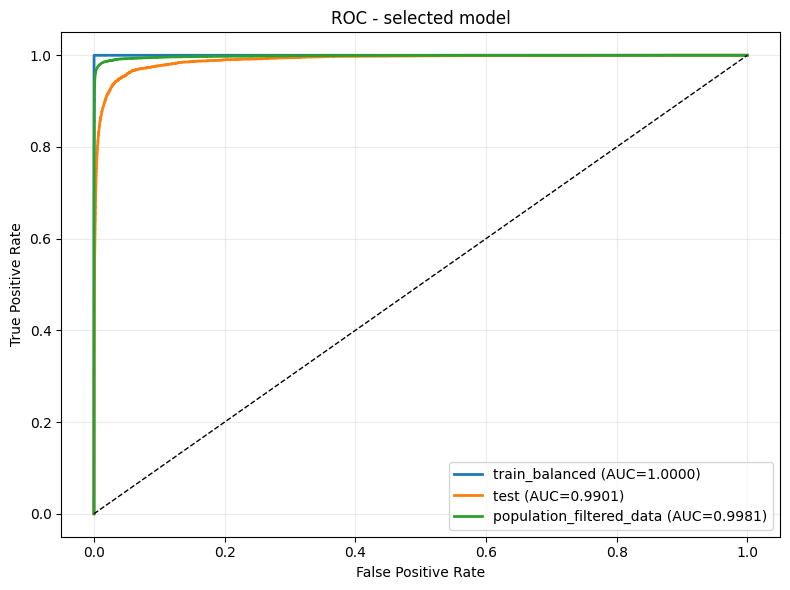

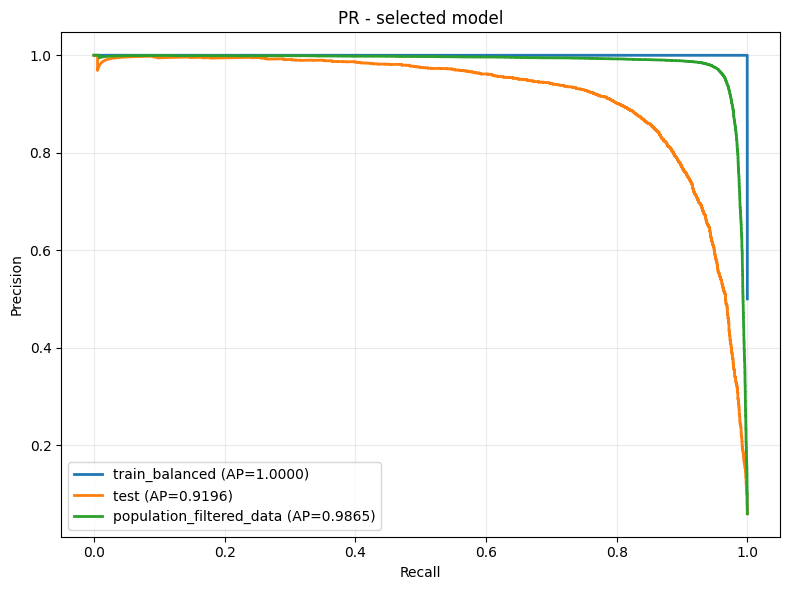

In [11]:
train_scores = predict_scores(selected_model, X_train_proc)
test_scores = predict_scores(selected_model, X_test_proc)
population_scores = predict_scores(selected_model, X_population_proc)

print("=" * 70)
print("ROC curves for the selected model")
_, _, roc_aucs = plot_auc_curves(
    [y_train_bal, y_test, y_population],
    [train_scores, test_scores, population_scores],
    names=["train_balanced", "test", "population_filtered_data"],
    curve="roc",
    title="ROC - selected model",
)
print(roc_aucs)

print("PR curves for the selected model")
_, _, pr_aucs = plot_auc_curves(
    [y_train_bal, y_test, y_population],
    [train_scores, test_scores, population_scores],
    names=["train_balanced", "test", "population_filtered_data"],
    curve="pr",
    title="PR - selected model",
)
print(pr_aucs)
